In [3]:
import os
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from PIL import Image
from collections import Counter

print("✅ Imports OK")

✅ Imports OK


In [1]:
import zipfile
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("✅ Imports OK")

# ── Chemins ──────────────────────────────────────────────
ZIP_PATH  = Path("C:/Users/pc/Documents/Food-101/Food-101.zip")  # ← adapte si besoin
DATA_DIR  = Path("C:/SmartMeal/data/food101")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"📦 ZIP trouvé : {ZIP_PATH.exists()}")
print(f"📂 Destination : {DATA_DIR}")

✅ Imports OK
📦 ZIP trouvé : True
📂 Destination : C:\SmartMeal\data\food101


In [3]:
EXTRACT_DIR = DATA_DIR

if not (EXTRACT_DIR / "food-101" / "images").exists():
    print("📦 Extraction en cours... (peut prendre 3-10 min selon ton PC)")
    print("⏳ Ne ferme pas Jupyter !")
    
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        members = z.namelist()
        total   = len(members)
        
        for i, member in enumerate(members):
            z.extract(member, EXTRACT_DIR)
            if i % 5000 == 0:
                pct = (i / total) * 100
                print(f"   {pct:.1f}% — {i:,} / {total:,} fichiers extraits...")
    
    print("✅ Extraction terminée !")
else:
    print("✅ Food-101 déjà extrait, on continue !")

# Vérification rapide
food101_dir = EXTRACT_DIR / "food-101"
images_dir  = food101_dir / "images"
meta_dir    = food101_dir / "meta"

print(f"\n📁 Structure détectée :")
print(f"   images/ existe : {images_dir.exists()}")
print(f"   meta/   existe : {meta_dir.exists()}")

📦 Extraction en cours... (peut prendre 3-10 min selon ton PC)
⏳ Ne ferme pas Jupyter !
   0.0% — 0 / 202,125 fichiers extraits...
   2.5% — 5,000 / 202,125 fichiers extraits...
   4.9% — 10,000 / 202,125 fichiers extraits...
   7.4% — 15,000 / 202,125 fichiers extraits...
   9.9% — 20,000 / 202,125 fichiers extraits...
   12.4% — 25,000 / 202,125 fichiers extraits...
   14.8% — 30,000 / 202,125 fichiers extraits...
   17.3% — 35,000 / 202,125 fichiers extraits...
   19.8% — 40,000 / 202,125 fichiers extraits...
   22.3% — 45,000 / 202,125 fichiers extraits...
   24.7% — 50,000 / 202,125 fichiers extraits...
   27.2% — 55,000 / 202,125 fichiers extraits...
   29.7% — 60,000 / 202,125 fichiers extraits...
   32.2% — 65,000 / 202,125 fichiers extraits...
   34.6% — 70,000 / 202,125 fichiers extraits...
   37.1% — 75,000 / 202,125 fichiers extraits...
   39.6% — 80,000 / 202,125 fichiers extraits...
   42.1% — 85,000 / 202,125 fichiers extraits...
   44.5% — 90,000 / 202,125 fichiers extra

In [5]:
# Voyons ce qui a été extrait exactement
print("📂 Contenu de data/food101 :")
for item in sorted(EXTRACT_DIR.iterdir()):
    print(f"   {item.name}  ({'dossier' if item.is_dir() else 'fichier'})")

print("\n📂 On cherche les images partout...")
# Chercher où sont les images
jpg_count = 0
for root, dirs, files in os.walk(EXTRACT_DIR):
    jpg_files = [f for f in files if f.endswith('.jpg')]
    if jpg_files:
        jpg_count += len(jpg_files)
        print(f"   ✅ {len(jpg_files)} images dans : {root}")
        break  # Affiche juste le premier dossier trouvé

if jpg_count == 0:
    print("   ⚠️ Aucune image .jpg trouvée")
    
print(f"\n🔍 Arborescence complète (3 niveaux) :")
def show_tree(path, level=0, max_level=3):
    if level > max_level:
        return
    for item in sorted(Path(path).iterdir())[:5]:  # max 5 par dossier
        print("   " * level + f"├── {item.name}")
        if item.is_dir():
            show_tree(item, level+1, max_level)

show_tree(EXTRACT_DIR)

📂 Contenu de data/food101 :
   food-101  (dossier)
   food-101.zip  (fichier)

📂 On cherche les images partout...
   ✅ 1000 images dans : C:\SmartMeal\data\food101\food-101\food-101\images\apple_pie

🔍 Arborescence complète (3 niveaux) :
├── food-101
   ├── __MACOSX
      ├── ._food-101
      ├── food-101
         ├── ._.DS_Store
         ├── ._images
         ├── ._license_agreement.txt
         ├── ._meta
         ├── ._README.txt
   ├── food-101
      ├── .DS_Store
      ├── images
         ├── .DS_Store
         ├── apple_pie
         ├── baby_back_ribs
         ├── baklava
         ├── beef_carpaccio
      ├── license_agreement.txt
      ├── meta
         ├── classes.txt
         ├── labels.txt
         ├── test.json
         ├── test.txt
         ├── train.json
      ├── README.txt
├── food-101.zip


In [6]:
# ── Chemins corrigés ─────────────────────────────────────
food101_dir = EXTRACT_DIR / "food-101" / "food-101"
images_dir  = food101_dir / "images"
meta_dir    = food101_dir / "meta"

print(f"✅ images/ : {images_dir.exists()}")
print(f"✅ meta/   : {meta_dir.exists()}")

# ── 101 catégories ───────────────────────────────────────
with open(meta_dir / "classes.txt") as f:
    classes = [line.strip() for line in f.readlines()]

print(f"\n📊 Nombre de catégories : {len(classes)}")
print(f"🍕 Exemples : {classes[:10]}")

# ── Compter les images par catégorie ─────────────────────
counts = {}
for cls in classes:
    counts[cls] = len(list((images_dir / cls).glob("*.jpg")))

df = pd.DataFrame(list(counts.items()), columns=["Food", "Count"])
df = df.sort_values("Count", ascending=False)

print(f"\n📈 Total images     : {df['Count'].sum():,}")
print(f"📈 Moyenne/classe   : {df['Count'].mean():.0f}")
print(f"📈 Min/classe       : {df['Count'].min()}")
print(f"📈 Max/classe       : {df['Count'].max()}")
print(f"\n🔝 Top 5 catégories :\n{df.head()}")

✅ images/ : True
✅ meta/   : True

📊 Nombre de catégories : 101
🍕 Exemples : ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']

📈 Total images     : 101,000
📈 Moyenne/classe   : 1000
📈 Min/classe       : 1000
📈 Max/classe       : 1000

🔝 Top 5 catégories :
             Food  Count
0       apple_pie   1000
1  baby_back_ribs   1000
2         baklava   1000
3  beef_carpaccio   1000
4    beef_tartare   1000


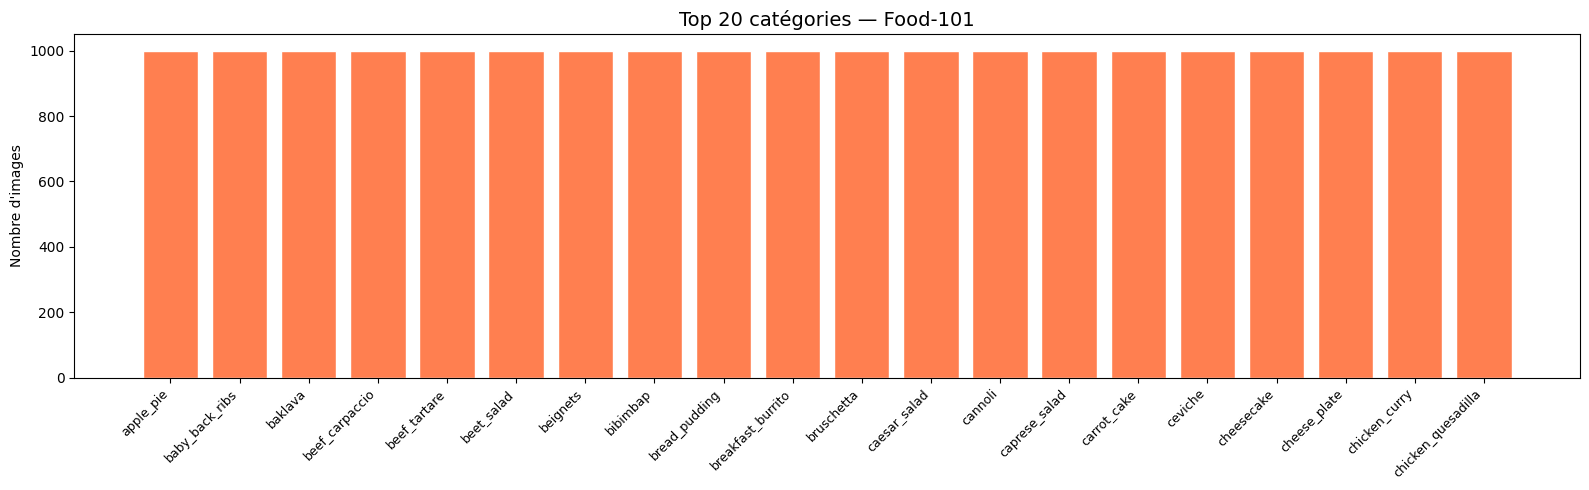

✅ Graphique sauvegardé dans reports/


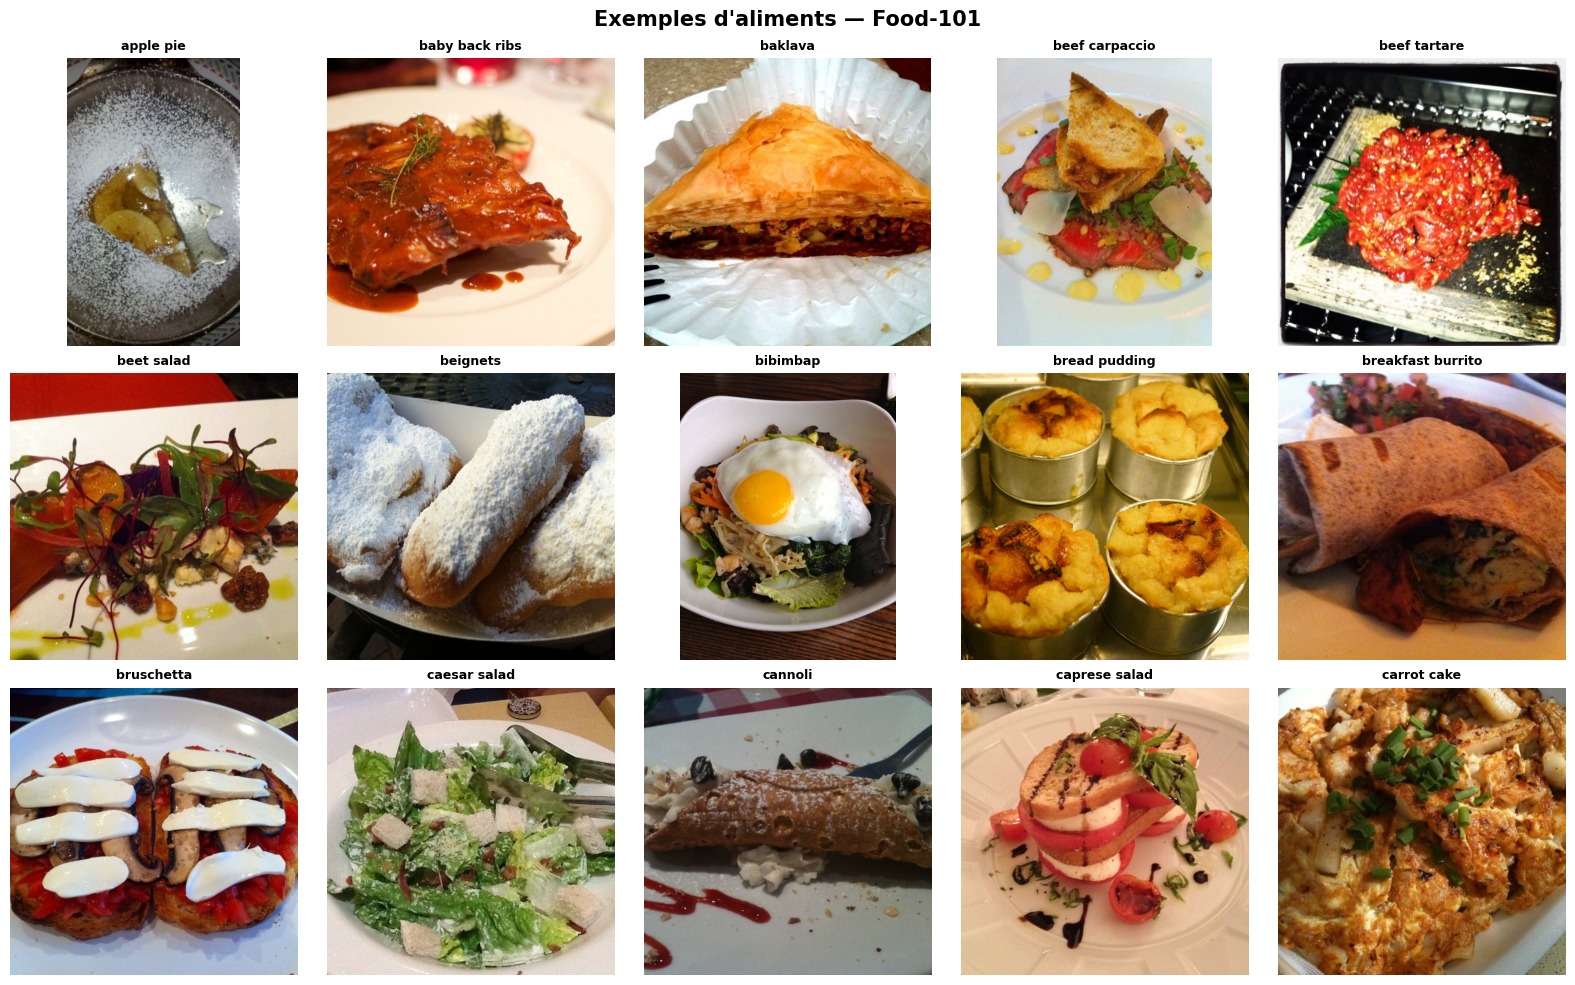

✅ Grille d'exemples sauvegardée


In [7]:
# ── Bar chart top 20 ─────────────────────────────────────
plt.figure(figsize=(16, 5))
plt.bar(df["Food"].head(20), df["Count"].head(20), color="coral", edgecolor="white")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.title("Top 20 catégories — Food-101", fontsize=14)
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.savefig("../reports/food101_distribution.png", dpi=150)
plt.show()
print("✅ Graphique sauvegardé dans reports/")

# ── Grille d'exemples ────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
sample_classes = classes[:15]

for ax, cls in zip(axes.flatten(), sample_classes):
    img_path = sorted((images_dir / cls).glob("*.jpg"))[0]
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls.replace("_", " "), fontsize=9, fontweight="bold")
    ax.axis("off")

plt.suptitle("Exemples d'aliments — Food-101", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/food101_exemples.png", dpi=150)
plt.show()
print("✅ Grille d'exemples sauvegardée")

In [8]:
# ── Train / Test split officiel ──────────────────────────
with open(meta_dir / "train.txt") as f:
    train_files = [l.strip() for l in f.readlines()]

with open(meta_dir / "test.txt") as f:
    test_files = [l.strip() for l in f.readlines()]

print(f"🟢 Train : {len(train_files):,} images (75%)")
print(f"🔴 Test  : {len(test_files):,} images (25%)")
print(f"\nExemple train : {train_files[0]}")
print(f"Exemple test  : {test_files[0]}")

# ── Résumé final ─────────────────────────────────────────
print(f"""
╔══════════════════════════════════════╗
║        FOOD-101 — RÉSUMÉ EDA        ║
╠══════════════════════════════════════╣
║  Catégories    : {len(classes):>4}                 ║
║  Total images  : {df['Count'].sum():>6,}               ║
║  Train         : {len(train_files):>6,}               ║
║  Test          : {len(test_files):>6,}               ║
║  Images/classe : {int(df['Count'].mean()):>4} en moyenne      ║
╚══════════════════════════════════════╝
""")

🟢 Train : 75,750 images (75%)
🔴 Test  : 25,250 images (25%)

Exemple train : apple_pie/1005649
Exemple test  : apple_pie/1011328

╔══════════════════════════════════════╗
║        FOOD-101 — RÉSUMÉ EDA        ║
╠══════════════════════════════════════╣
║  Catégories    :  101                 ║
║  Total images  : 101,000               ║
║  Train         : 75,750               ║
║  Test          : 25,250               ║
║  Images/classe : 1000 en moyenne      ║
╚══════════════════════════════════════╝



In [10]:
import json

# Sauvegarder la config du projet pour les prochains notebooks
config = {
    "food101_dir"  : str(food101_dir),
    "images_dir"   : str(images_dir),
    "meta_dir"     : str(meta_dir),
    "num_classes"  : len(classes),
    "total_images" : int(df['Count'].sum()),
    "train_size"   : len(train_files),
    "test_size"    : len(test_files),
    "classes"      : classes
}

config_path = Path("C:/SmartMeal/src/config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"✅ Config sauvegardée : {config_path}")
print(f"📋 Contenu : {list(config.keys())}")






✅ Config sauvegardée : C:\SmartMeal\src\config.json
📋 Contenu : ['food101_dir', 'images_dir', 'meta_dir', 'num_classes', 'total_images', 'train_size', 'test_size', 'classes']
